# Régression gaussienne: étude sur données synthétiques et réelles


In [1]:
import numpy as np
import scipy.stats as scs
import matplotlib.pyplot as plt
import sklearn
import sklearn.gaussian_process
import scipy.optimize as sco
import pandas as pd
import scipy.linalg as sla

## 1) Fonction génératrice sans bruit

On définit la fonction cible $f(x) = x \sin(x)$ sur un maillage régulier.

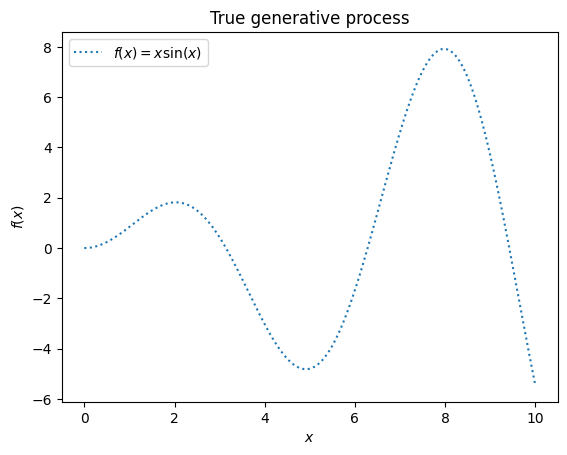

In [2]:
X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

## 2) GP de base sur quelques observations

On tire 6 points d'apprentissage, puis on ajuste un processus gaussien avec le kernel par défaut, RBF.

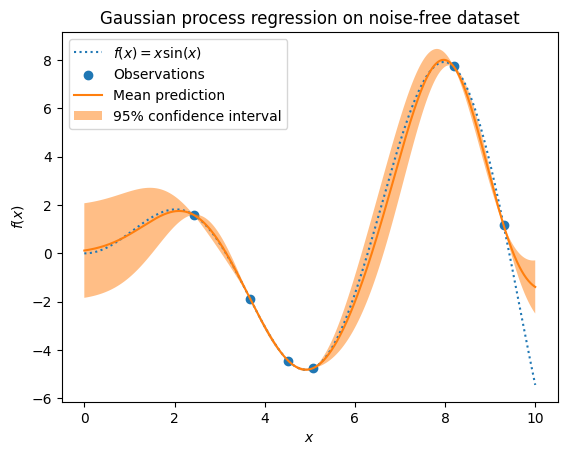

In [3]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor()
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

## 3) GP avec noyau linéaire (DotProduct)

On impose un noyau de type produit scalaire, comme demandé dans le sujet, pour comparer le comportement.

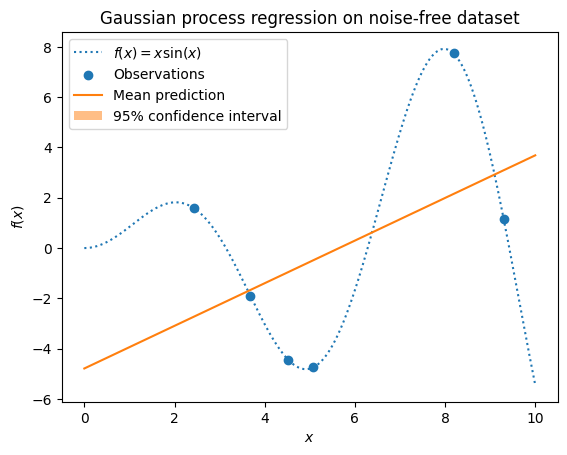

In [4]:
from sklearn.gaussian_process.kernels import DotProduct
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(kernel=DotProduct())
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

On constate que le modèle de régression linéaire (DotProduct) ne parvient pas à capturer la nature non linéaire de la fonction $f(x) = x \sin(x)$, ce qui se traduit par une prédiction très médiocre et une incertitude élevée. En revanche, le modèle de régression gaussienne avec un noyau plus approprié (comme le RBF) peut mieux s'adapter à la complexité de la fonction. Nous verrons donc par la suite si l'hypothèse de linéarité de l'énoncé semble appropriée.

## 4) Données synthétiques bruitées

On génère des observations linéaires bruitées puis on ajuste un GP adapté au bruit gaussien.

In [5]:
sigma = 1
d = 1
np.random.seed(2)
w = np.random.randn(d)
eps = scs.norm.rvs(loc=0, scale=sigma, size=X.shape[0])
y = np.dot(X, w) + eps
training_indices = np.random.choice(np.arange(y.size), size=6, replace=False)

Proportion des données dans l'intervalle de confiance à 95% : 0.9490


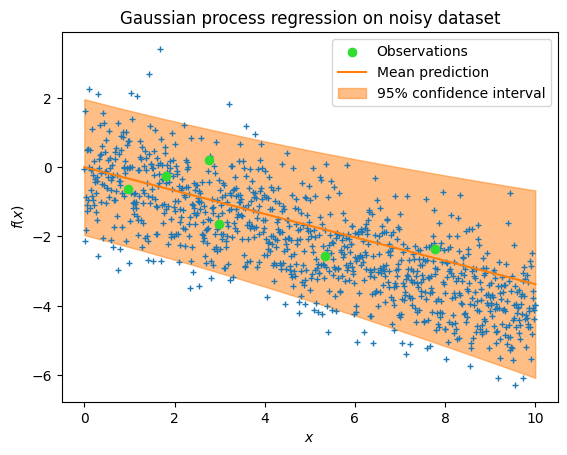

In [9]:
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(
    kernel=DotProduct(sigma_0=0, sigma_0_bounds="fixed"),
    alpha=sigma**2,
    
)
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
std_pred_bruitee = np.sqrt(std_prediction**2 + sigma**2)
plt.plot(X, y, linestyle="", marker="+", markersize=4)
plt.scatter(X_train, y_train, label="Observations", color="#30DD30", zorder=3)
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_pred_bruitee,
    mean_prediction + 1.96 * std_pred_bruitee,
    alpha=0.5,
    label=r"95% confidence interval",
    color="C1"
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noisy dataset")

# On calcule la proportion des données dans l'intervalle de confiance à 95%
lower_bound = mean_prediction - 1.96 * std_pred_bruitee
upper_bound = mean_prediction + 1.96 * std_pred_bruitee
proportion_in_interval = np.mean((y >= lower_bound) & (y <= upper_bound))
print(f"Proportion des données dans l'intervalle de confiance à 95% : {proportion_in_interval:.4f}")

## 5) Jeu de données Airfoil

On charge les données réelles, puis on réalise une PCA pour visualiser la structure.

In [10]:
df = pd.read_csv(
    "./data/airfoil_self_noise.dat",
    sep="\t",
    header=None,
    names=[
        "Frequency",
        "Angle of attack",
        "Chord length",
        "Free-stream velocity",
        "Suction side displacement thickness",
        "Scaled sound pressure level"
    ]
)

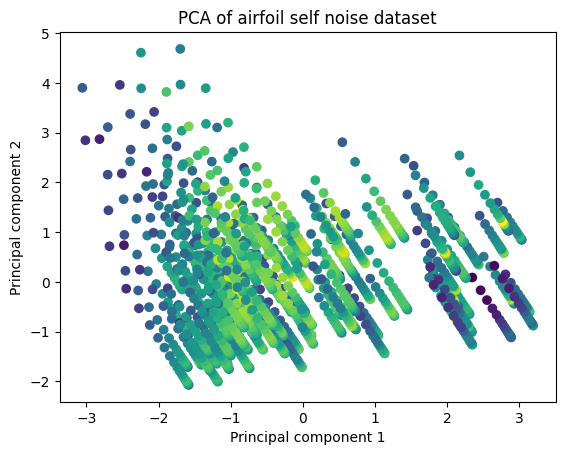

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

n_comp = 2
X = df.drop(columns=["Scaled sound pressure level"]).values

def pipeline_pca(n_comp):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp))
    ])
    return pipeline

X_pca = pipeline_pca(n_comp).fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Scaled sound pressure level"], cmap="viridis")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
_ = plt.title("PCA of airfoil self noise dataset")

Pas super utile

## 6) Régression gaussienne sur Airfoil (scikit-learn)

On sépare apprentissage/test, on standardise les variables, puis on évalue la vraisemblance prédictive.

In [21]:
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

scaler = StandardScaler()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    df["Scaled sound pressure level"],
    test_size=0.2,
    random_state=42
)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor()
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X_test, return_std=True)

var_pred = std_prediction**2
log_likelihoods = -0.5 * (
    np.log(2 * np.pi * var_pred)
    + (y_test - mean_prediction)**2 / var_pred
)
mean_log_likelihood = np.mean(log_likelihoods)

print("1.")
print("kernel par défaut :", gaussian_process.kernel_)
print("Mean predictive log-likelihood:", mean_log_likelihood)


gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(kernel=ConstantKernel(1.0, constant_value_bounds="fixed") * RBF(1.0, length_scale_bounds="fixed") + WhiteKernel())
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X_test, return_std=True)

var_pred = std_prediction**2
log_likelihoods = -0.5 * (
    np.log(2 * np.pi * var_pred)
    + (y_test - mean_prediction)**2 / var_pred
)
mean_log_likelihood = np.mean(log_likelihoods)

print("2.")
print("kernel par défaut avec un bruit:", gaussian_process.kernel_)
print("Mean predictive log-likelihood:", mean_log_likelihood)



gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(
    kernel=DotProduct() + WhiteKernel()
)

gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X_test, return_std=True)

var_pred = std_prediction**2
log_likelihoods = -0.5 * (
    np.log(2 * np.pi * var_pred)
    + (y_test - mean_prediction)**2 / var_pred
)
mean_log_likelihood = np.mean(log_likelihoods)
total_log_likelihood = np.sum(log_likelihoods)

print("3.")
print("kernel du produit scalaire avec un bruit:", gaussian_process.kernel_)
print("Mean predictive log-likelihood:", mean_log_likelihood)
print("Total predictive log-likelihood:", total_log_likelihood)

lower1 = mean_prediction - 1.96 * std_prediction
upper1 = mean_prediction + 1.96 * std_prediction
coverage1 = np.mean((y_test >= lower1) & (y_test <= upper1))
print("Coverage avec std_prediction :", coverage1)


1.
kernel par défaut : 1**2 * RBF(length_scale=1)
Mean predictive log-likelihood: -6641116408.606631
2.
kernel par défaut avec un bruit: 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1.54e+04)
Mean predictive log-likelihood: -6.238388562413166
3.
kernel du produit scalaire avec un bruit: DotProduct(sigma_0=125) + WhiteKernel(noise_level=23.4)
Mean predictive log-likelihood: -2.972206065433264
Total predictive log-likelihood: -894.6340256954124
Coverage avec std_prediction : 0.9501661129568106


On constate donc que le kernel linéaire est bien adapté aux données. Toutefois, au vu de la valeur estimée du biais on ne peut se restreindre au cas linéaire, on considère donc le modèle affine.

## 7) Implémentation à la main de la régression gaussienne

On reproduit la même idée avec une classe personnalisée et une estimation des hyperparamètres par maximum de vraisemblance.

In [17]:
class reg_gaussienne:
    def __init__(self, sigma_0=None, sigma=None):
        self.sigma_0 = sigma_0
        self.sigma = sigma
        self.fitted = False
        self.K_inv = None
        self.gammaW = None
        self.gammaW_X_T = None
        self.X = None
        self.y = None
        self.n = None
        self.biais = None

    def fit(self, X, y):
        self.X = X
        self.y = y
        n, p = X.shape
        self.n = n
        self.gammaW = np.eye(p)
        self.gammaW_X_T = self.gammaW @ X.T

        if self.sigma_0 is None and self.sigma is None:
            log_sigma_0, log_sigma = sco.minimize(
                lambda params: self.neg_log_vraissemblance(params[0], params[1]),
                x0=np.log([1, 1]),
                method="L-BFGS-B"
            ).x
            self.sigma_0 = np.exp(log_sigma_0)
            self.sigma = np.exp(log_sigma)
        elif self.sigma_0 is None:
            log_sigma_0 = sco.minimize(
                lambda log_sigma_0: self.neg_log_vraissemblance(log_sigma_0[0], self.sigma),
                x0=np.log([1]),
                method="L-BFGS-B"
            ).x[0]
            self.sigma_0 = np.exp(log_sigma_0)
        elif self.sigma is None:
            log_sigma = sco.minimize(
                lambda log_sigma: self.neg_log_vraissemblance(self.sigma_0, log_sigma[0]),
                x0=np.log([1]),
                method="L-BFGS-B"
            ).x[0]
            self.sigma = np.exp(log_sigma)

        print(f"Optimized sigma_0: {self.sigma_0}, Optimized sigma2: {self.sigma**2}")

        K = X @ self.gammaW @ X.T + self.sigma_0**2 * np.ones((n, n)) + self.sigma**2 * np.eye(n) + 1e-8 * np.eye(self.n)
        self.K_inv = np.linalg.inv(K)
        self.biais = self.sigma_0**2 * np.ones((self.n, 1)).T
        self.fitted = True

    def pred(self, X_0):
        if not self.fitted:
            raise ValueError("Model must be fitted before prediction.")

        X_0 = X_0.T
        k_star = X_0.T @ self.gammaW_X_T + self.biais
        esp = k_star @ self.K_inv @ self.y
        var = self.sigma**2 + self.sigma_0**2 + X_0.T @ self.gammaW @ X_0
        var = var - k_star @ self.K_inv @ k_star.T
        return esp, var

    def neg_log_vraissemblance(self, log_sigma_0, log_sigma):
        sigma_0 = np.exp(log_sigma_0)
        sigma = np.exp(log_sigma)
        K = self.X @ self.gammaW @ self.X.T + sigma_0**2 * np.ones((self.n, self.n)) + sigma**2 * np.eye(self.n) + 1e-8 * np.eye(self.n)
        try:
            L = np.linalg.cholesky(K)
        except np.linalg.LinAlgError:
            return np.inf

        alpha = sla.cho_solve((L, True), self.y)
        nll = 0.5 * self.y.T @ alpha
        nll += np.sum(np.log(np.diag(L)))
        nll += 0.5 * self.n * np.log(2 * np.pi)
        return float(nll)


sigma_0 = None
sigma = None

def regression_gaussienne(X_train, y_train, X_test):
    model = reg_gaussienne(sigma_0, sigma)
    model.fit(X_train, y_train)
    mean_prediction, var_prediction = model.pred(X_test)
    return mean_prediction, np.diag(var_prediction)

## 8) Comparaison des performances et visualisation

On calcule les métriques prédictives de l'implémentation maison, puis on visualise la prédiction en espace PCA 1D.

In [18]:
mean_prediction_custom, var_prediction_custom = regression_gaussienne(X_train, y_train, X_test)

log_likelihoods = -0.5 * (
    np.log(2 * np.pi * var_prediction_custom)
    + (y_test - mean_prediction_custom)**2 / var_prediction_custom
)

mean_log_likelihood = np.mean(log_likelihoods)
total_log_likelihood = np.sum(log_likelihoods)

print("Mean predictive log-likelihood:", mean_log_likelihood)
print("Total predictive log-likelihood:", total_log_likelihood)

lower1 = mean_prediction_custom - 1.96 * np.sqrt(var_prediction_custom)
upper1 = mean_prediction_custom + 1.96 * np.sqrt(var_prediction_custom)
coverage1 = np.mean((y_test >= lower1) & (y_test <= upper1))
print("Coverage avec std_prediction :", coverage1)

Optimized sigma_0: 124.95813139206064, Optimized sigma2: 23.43298821935298
Mean predictive log-likelihood: -2.972202594013084
Total predictive log-likelihood: -894.6329807979382
Coverage avec std_prediction : 0.9501661129568106


On a donc presque les même résultats que l'implémentation de sklearn.

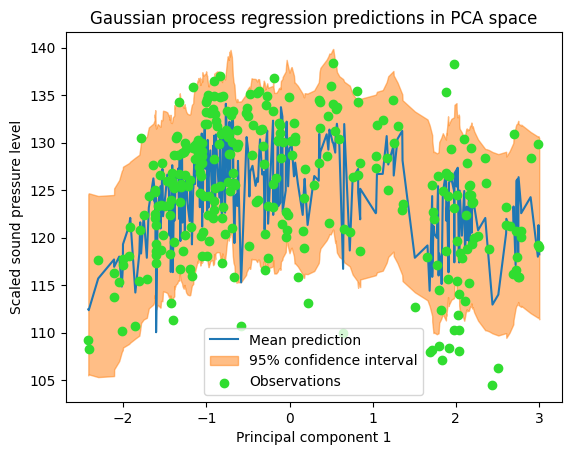

In [19]:
from scipy.ndimage import uniform_filter1d

X_test_pca = pipeline_pca(1).fit_transform(X_test)
sorted_indices = np.argsort(X_test_pca[:, 0])
X_test_pca_sorted = X_test_pca[sorted_indices]
mean_prediction_sorted = mean_prediction_custom[sorted_indices]
var_prediction_sorted = var_prediction_custom[sorted_indices]

plt.plot(X_test_pca_sorted[:, 0], mean_prediction_sorted, label="Mean prediction")

lower = mean_prediction_sorted - 1.96 * np.sqrt(var_prediction_sorted)
upper = mean_prediction_sorted + 1.96 * np.sqrt(var_prediction_sorted)
lower_smooth = uniform_filter1d(lower, size=10)
upper_smooth = uniform_filter1d(upper, size=10)
plt.fill_between(
    X_test_pca_sorted[:, 0],
    lower_smooth,
    upper_smooth,
    alpha=0.5,
    label=r"95% confidence interval",
    color="C1"
)

plt.scatter(X_test_pca[:, 0], y_test, label="Observations", color="#30DD30", zorder=3)
plt.xlabel("Principal component 1")
plt.ylabel("Scaled sound pressure level")
plt.title("Gaussian process regression predictions in PCA space")
plt.legend()